<a href="https://colab.research.google.com/github/rodrigorissettoterra/SENAI_Concepcao_e_Design_de_ML/blob/main/Classifica%C3%A7%C3%A3o_de_esp%C3%A9cies_de_flores_(%C3%8Dris).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ATIVIDADE - Classificação de espécies de flores (Íris)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Carregar dataset

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

# Criar DataFrame
df = pd.DataFrame(X, columns=feature_names)
df["species"] = y

print("Shape da base:", df.shape)

print("\nPrimeiras linhas:")
print(df.head())

Shape da base: (150, 5)

Primeiras linhas:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


Análise exploratória

In [3]:
print("\nDistribuição das classes:")
print(df["species"].value_counts())


Distribuição das classes:
species
0    50
1    50
2    50
Name: count, dtype: int64


Visualização (correlação)

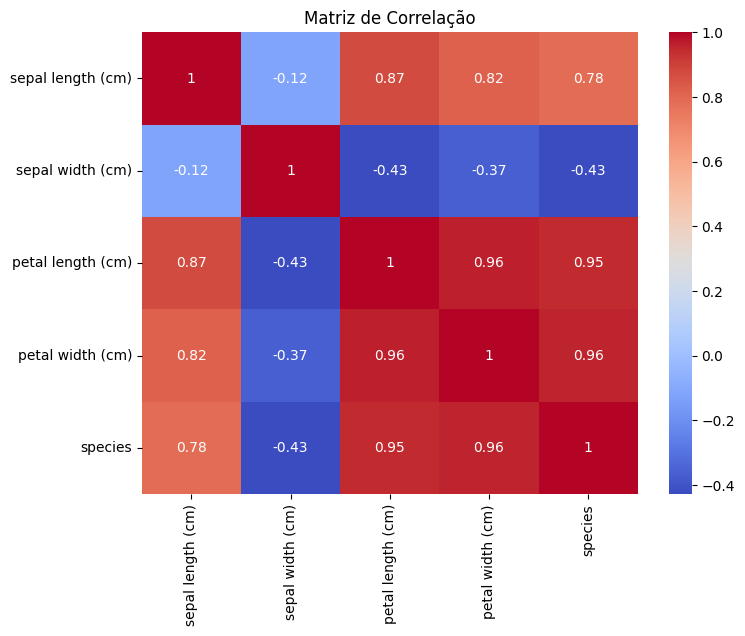

In [4]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

Separar variáveis

In [5]:
X = df.drop("species", axis=1)
y = df["species"]

Divisão treino/teste

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTreino:", X_train.shape)
print("Teste:", X_test.shape)


Treino: (120, 4)
Teste: (30, 4)


Normalização

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Modelo de classificação

In [8]:
modelo = KNeighborsClassifier(n_neighbors=5)
modelo.fit(X_train_scaled, y_train)

KNeighborsClassifier()

Predição

In [9]:
y_pred = modelo.predict(X_test_scaled)

Avaliação

In [10]:
acc = accuracy_score(y_test, y_pred)

print("\nAcurácia:", acc)

print("\nRelatório de classificação:\n")
print(classification_report(y_test, y_pred, target_names=target_names))


Acurácia: 0.9333333333333333

Relatório de classificação:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



Matriz de confusão

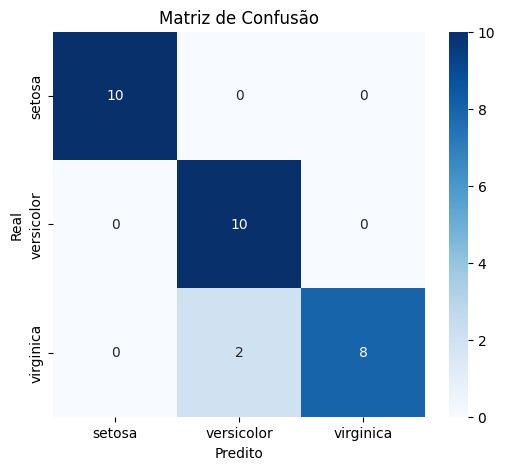

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

Exemplo de previsão

In [12]:
exemplo = X_test.iloc[[0]]
exemplo_scaled = scaler.transform(exemplo)

predicao = modelo.predict(exemplo_scaled)[0]

print("\nExemplo de previsão:")
print("Classe real:", target_names[y_test.iloc[0]])
print("Classe prevista:", target_names[predicao])


Exemplo de previsão:
Classe real: setosa
Classe prevista: setosa
